In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1883785          0                       1                       12   
1   1894783          1                       7                        6   
2  30579330          0                      11                        1   
3   1741000          1                       3                        3   
4  38984295          1                      10                        2   

   team0_team_total_networth  team0_team_total_damage  \
0                      13887                     8466   
1                      19112                    10496   
2                      23988                    11508   
3                      17747                    12237   
4                      29172                    17575   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                                28              5.666667   
1                              1565              6.500000   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    9311
0    9181
Name: count, dtype: int64
team0_won
1    0.503515
0    0.496485
Name: proportion, dtype: float64


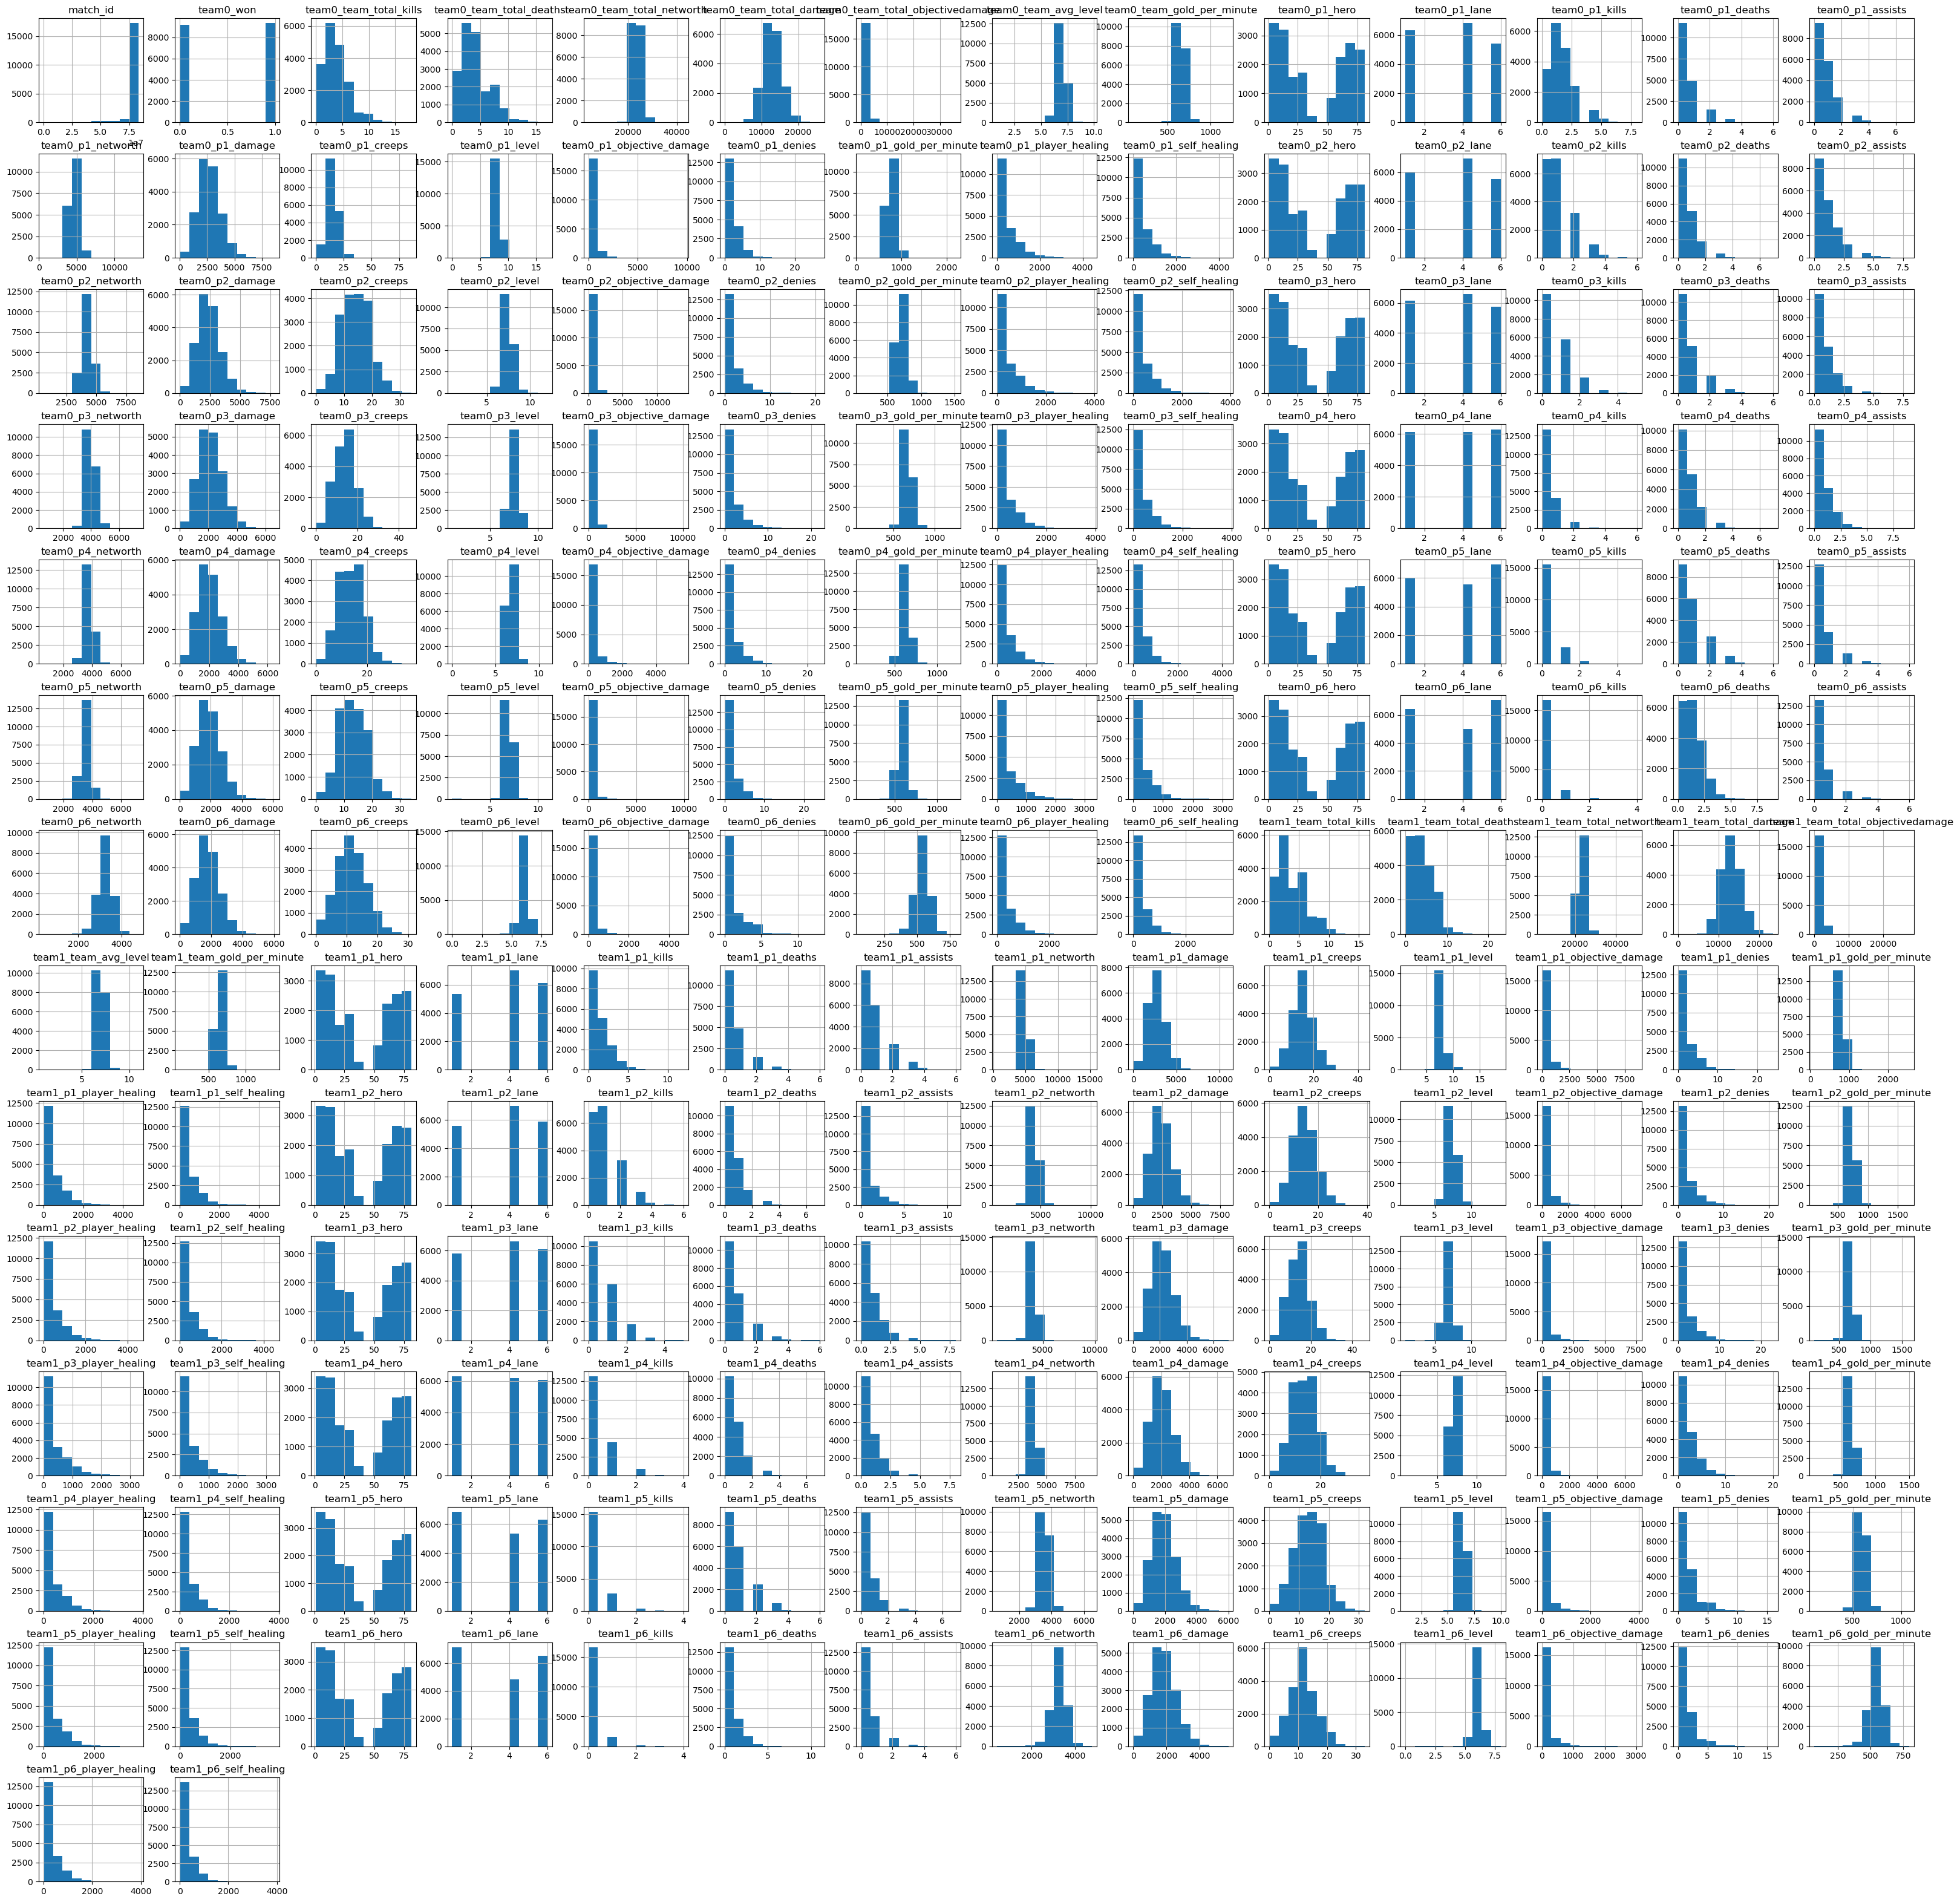

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count    18492.000000
mean     23324.622431
std       1833.534157
min       3600.000000
25%      22102.750000
50%      23231.000000
75%      24435.000000
max      42836.000000
Name: team0_team_total_networth, dtype: float64


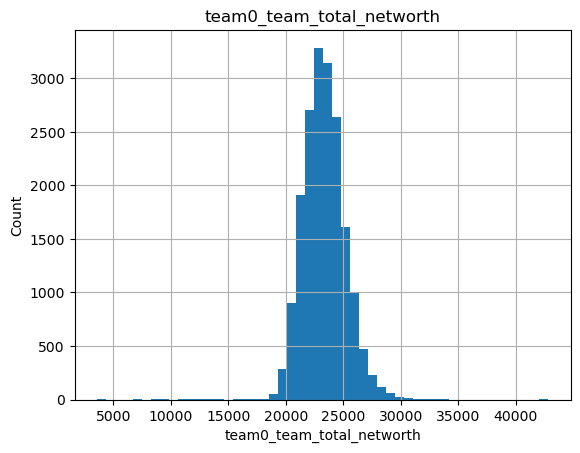

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [7]:
threshold = 40000

count = (df["team0_team_total_networth"] > threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] > 40000]

print((outliers.head(20)))

1
     match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
250  49652083          1                       3                        2   

     team0_team_total_networth  team0_team_total_damage  \
250                      42836                     2927   

     team0_team_total_objectivedamage  team0_team_avg_level  \
250                             36134              9.833333   

     team0_team_gold_per_minute  team0_p1_hero  ...  team1_p6_assists  \
250                 1206.647683             66  ...                 0   

     team1_p6_networth  team1_p6_damage  team1_p6_creeps  team1_p6_level  \
250                869                0                0               1   

     team1_p6_objective_damage  team1_p6_denies  team1_p6_gold_per_minute  \
250                          0                0                146.873215   

     team1_p6_player_healing  team1_p6_self_healing  
250                        0                      0  

[1 rows x 184 columns]


# Inspecting Correlations

In [8]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                     1.000000
team0_team_gold_per_minute    0.197171
team0_team_total_networth     0.197133
team0_team_avg_level          0.177879
team0_p5_gold_per_minute      0.173034
                                ...   
team1_p2_gold_per_minute     -0.154746
team1_team_total_kills       -0.156329
team1_team_avg_level         -0.166892
team1_team_total_networth    -0.185236
team1_team_gold_per_minute   -0.185378
Name: team0_won, Length: 184, dtype: float64
